# Predict Customer Churn - Exploratory Data Analysis (EDA)

This notebook performs basic Exploratory Data Analysis on the dataset to help understand distributions, feature interactions, and potential data quality issues before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading & Basic Inspection

In [2]:
DATA_DIR = '../data/'
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

# Map target if necessary
if train_df['Churn'].dtype == 'object':
    train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0, '1': 1, '0': 0})

train_df.head()

Training data shape: (594194, 21)
Testing data shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [4]:
# Missing values check
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

## 2. Target Variable Distribution (`Churn`)
Understanding the class balance is critical. If heavily imbalanced, it dictates our cross-validation strategies (Stratified K-Fold) and evaluation metrics.

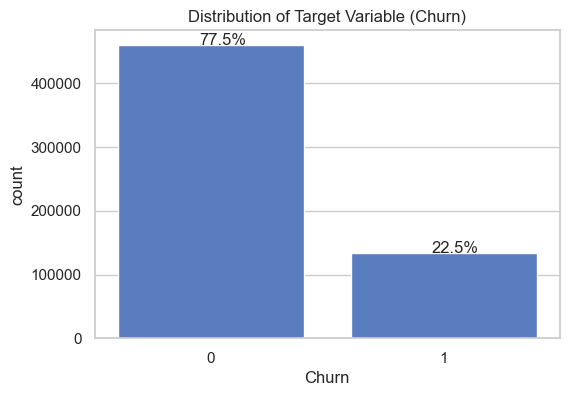

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=train_df)
plt.title('Distribution of Target Variable (Churn)')

# Add percentage annotations
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size=12)
    
plt.show()

## 3. Numerical Features Analysis
Visualizing continuous features (`tenure`, `MonthlyCharges`, `TotalCharges`) against the target class to observe density overlaps and deviations.

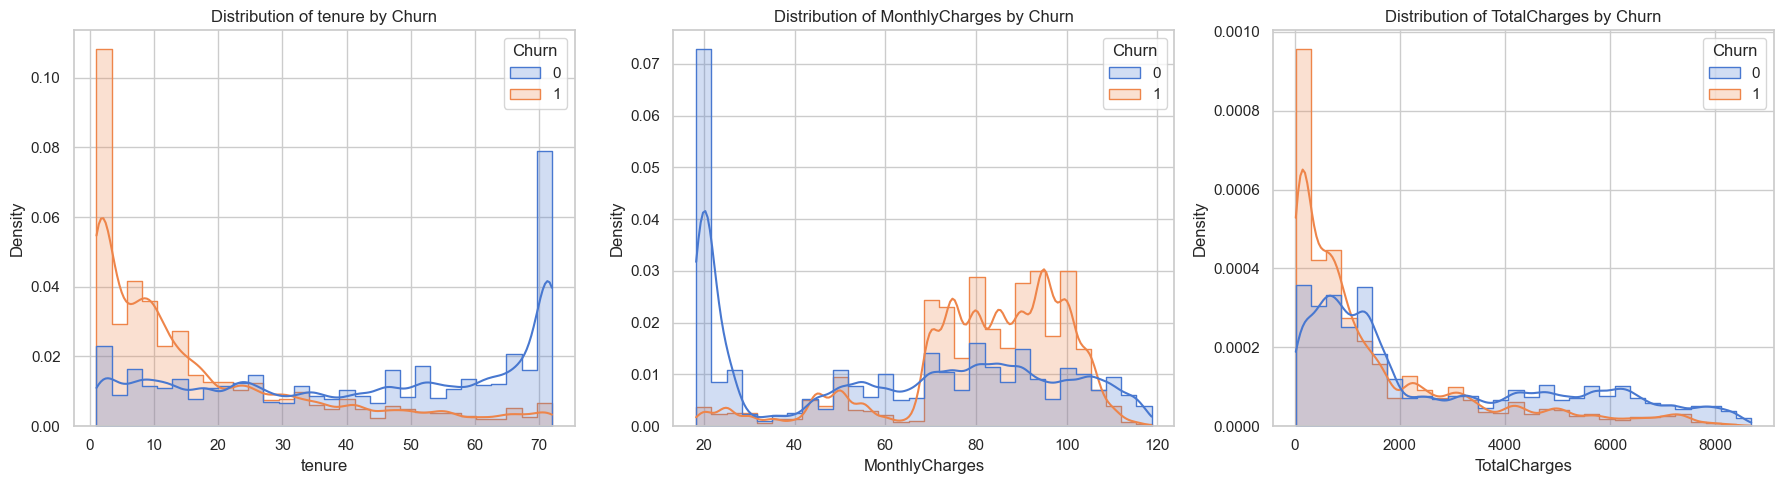

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    if col in train_df.columns:
        sns.histplot(data=train_df, x=col, hue='Churn', kde=True, bins=30, ax=axes[i], element="step", stat="density", common_norm=False)
        axes[i].set_title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

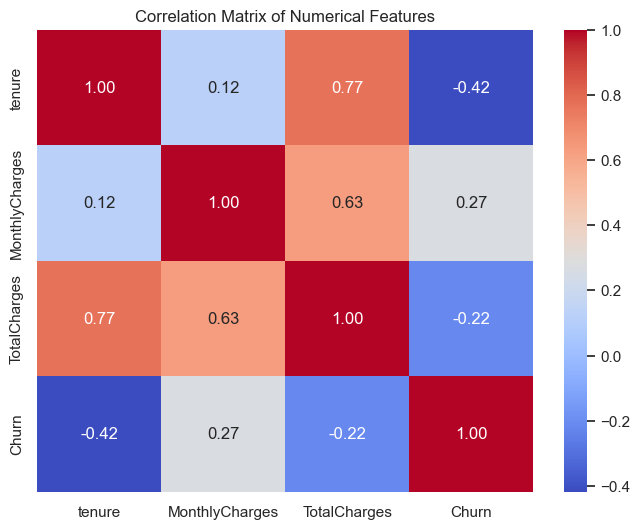

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 4. Categorical Features Analysis
Let's look at churn rates across different categorical groupings to see which demographics or service tiers are more prone to churning.

Categorical columns to plot: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


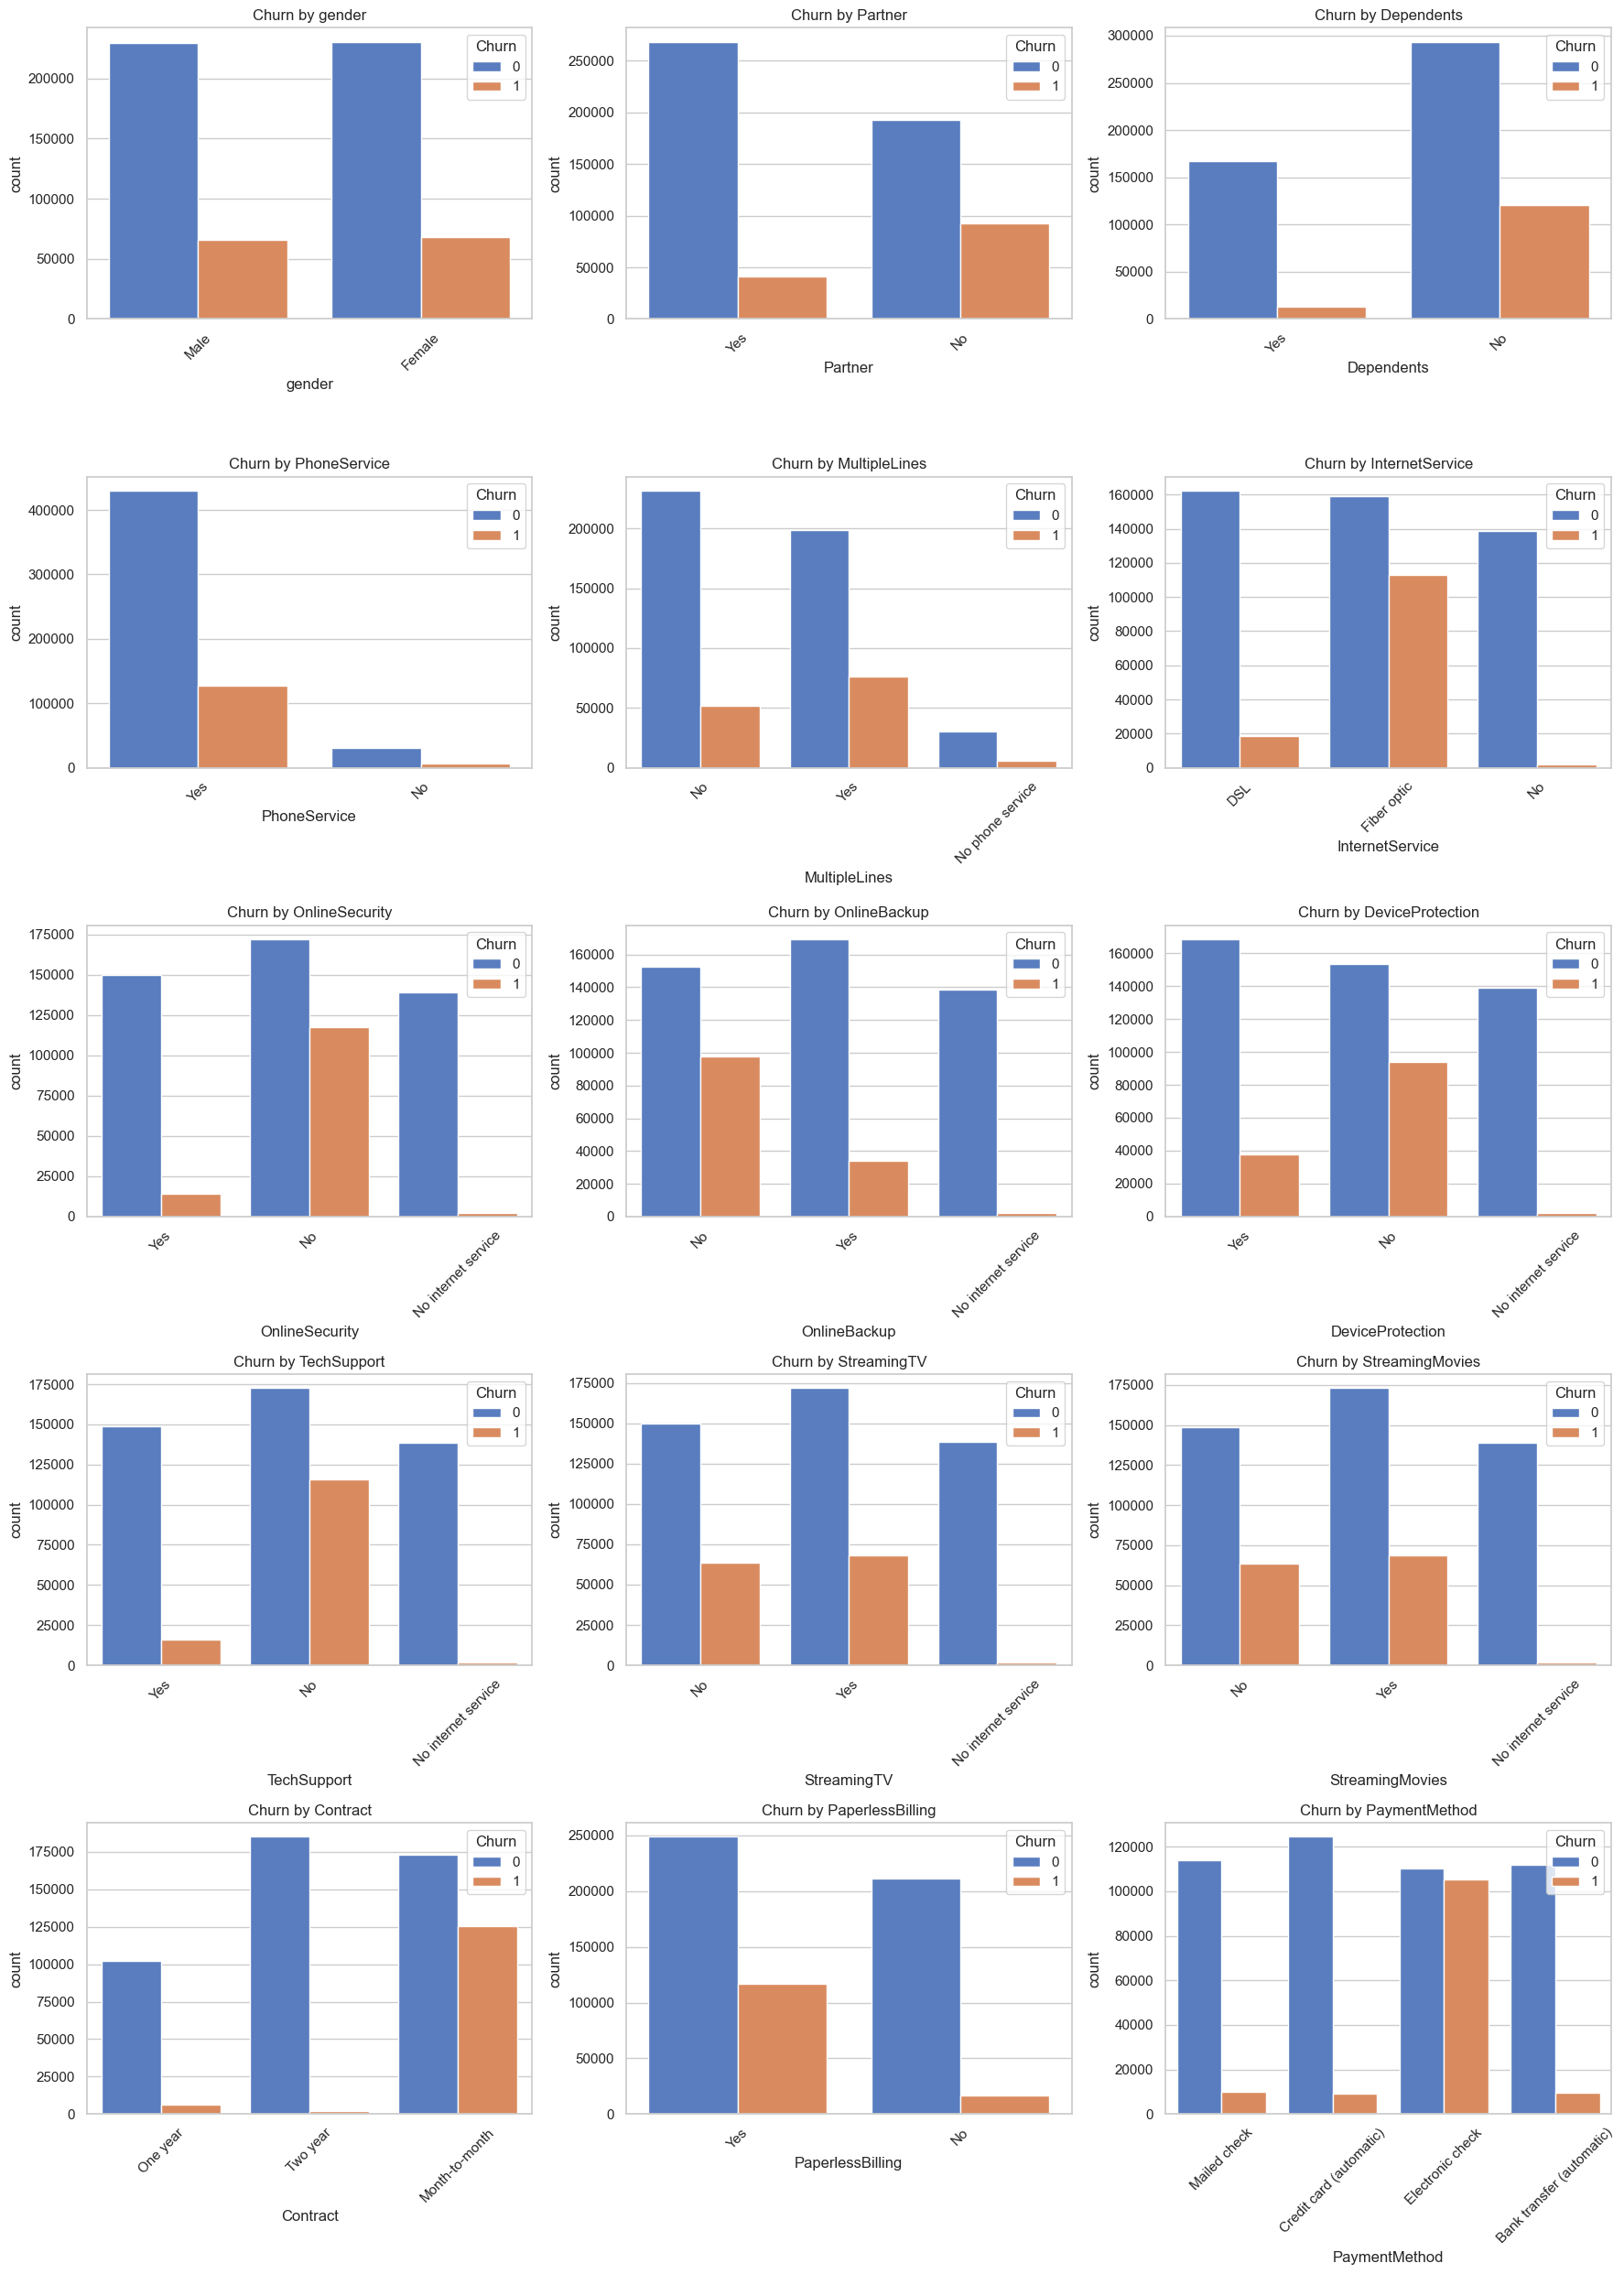

In [8]:
cat_cols = [c for c in train_df.columns if train_df[c].dtype == 'object' and c != 'id' and train_df[c].nunique() < 10]

print(f"Categorical columns to plot: {cat_cols}")

# Calculate rows/cols for subplots
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=train_df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 5. Bivariate / Interaction Plotting
Investigating if combinations of certain numeric traits highlight churn density more prominently.

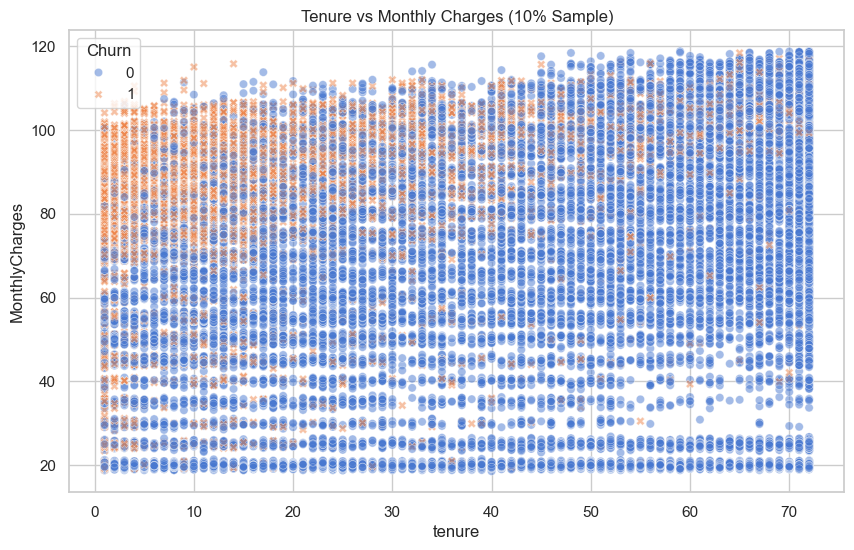

In [9]:
if 'tenure' in train_df.columns and 'MonthlyCharges' in train_df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=train_df.sample(frac=0.1, random_state=42),  # sample 10% for rendering speed
                    x='tenure', y='MonthlyCharges', 
                    hue='Churn', alpha=0.5, style='Churn')
    plt.title('Tenure vs Monthly Charges (10% Sample)')
    plt.show()

## 6. Global Feature Correlation (Categoricals Encoded)
Converting all categorical variables to numerical values via Label Encoding to observe their global linear correlation with the `Churn` target.

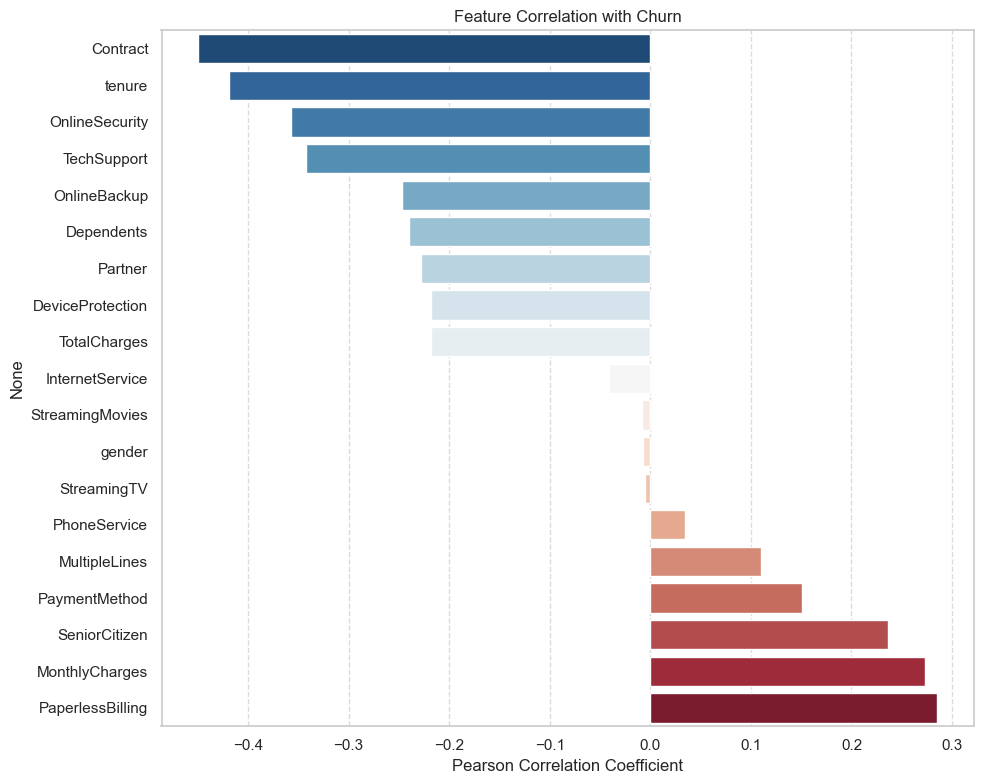

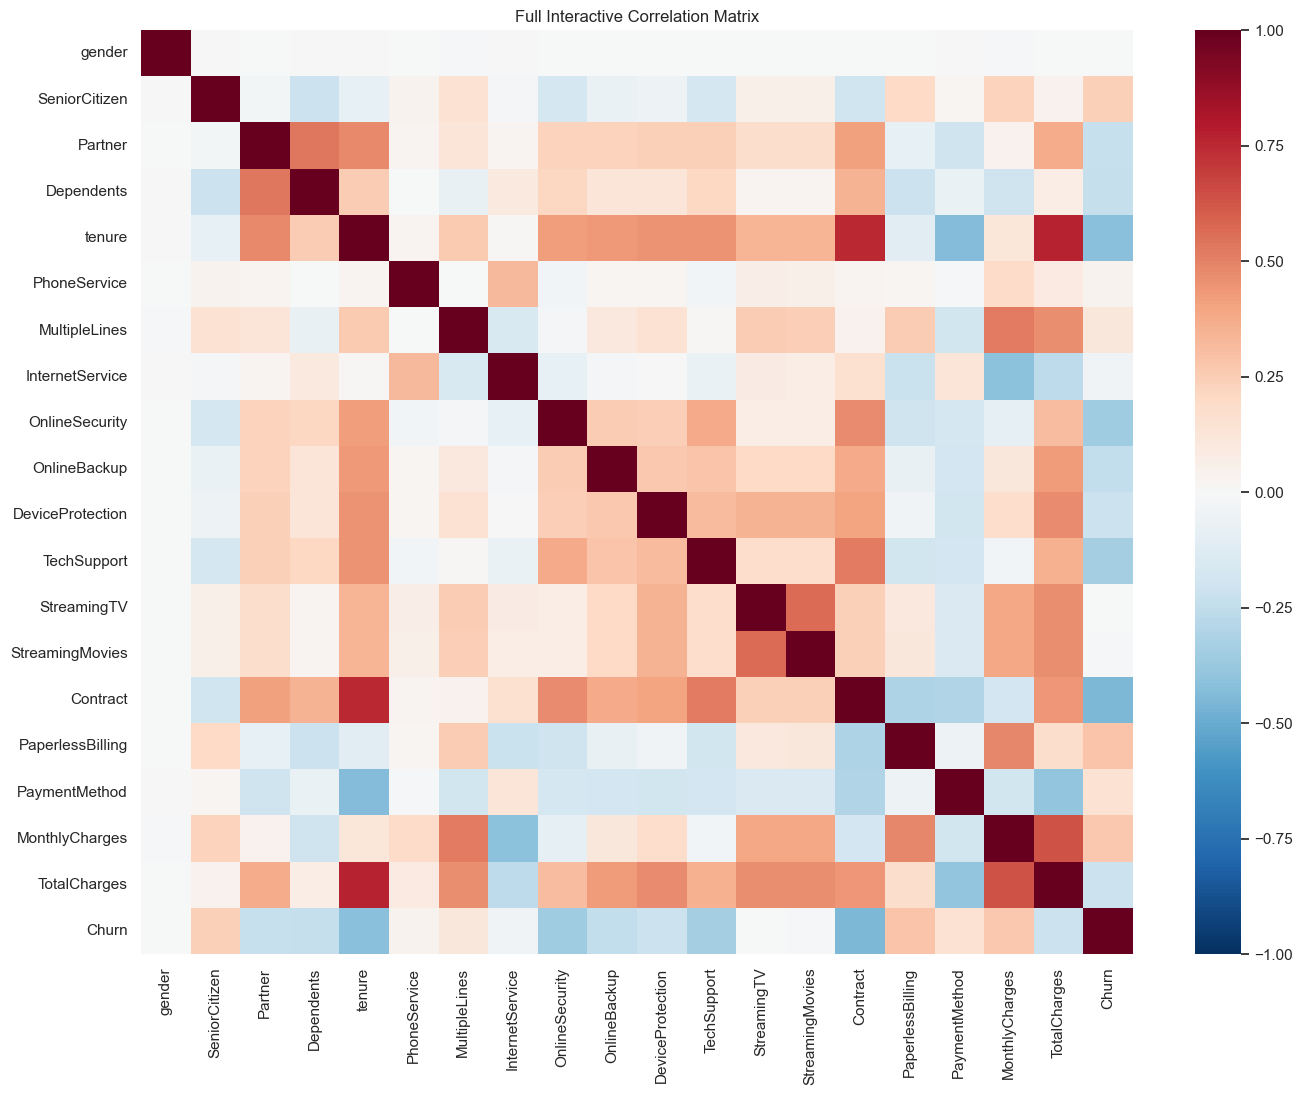

In [10]:
from sklearn.preprocessing import LabelEncoder

corr_df = train_df.copy()
cat_cols = corr_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col != 'id':
        corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))

# Compute numerical correlations across the entire board
cols_to_use = [c for c in corr_df.columns if c != 'id']
full_corr = corr_df[cols_to_use].corr()

# Plot correlation specifically targeting Churn
plt.figure(figsize=(10, 8))
churn_corr = full_corr['Churn'].drop('Churn').sort_values()
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette='RdBu_r')
plt.title('Feature Correlation with Churn')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Render the complete matrix heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(full_corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Full Interactive Correlation Matrix')
plt.show()
